In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Task 1

In [6]:
df = pd.read_csv('gym.csv')

df.head()

,age,gender,weight,height,max_bpm,avg_bpm,resting_bpm,session_duration,calories_burned,workout_type,fat_percentage,water_intake,workout_frequency,experience_level,bmi
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


In [7]:
df.describe()

,age,weight,height,max_bpm,avg_bpm,resting_bpm,session_duration,calories_burned,fat_percentage,water_intake,workout_frequency,experience_level,bmi
count,973.000000,973.000000,973.00000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000
mean,38.683453,73.854676,1.72258,179.883864,143.766701,62.223022,1.256423,905.422405,24.976773,2.626619,3.321686,1.809866,24.912127
std,12.180928,21.207500,0.12772,11.525686,14.345101,7.327060,0.343033,272.641516,6.259419,0.600172,0.913047,0.739693,6.660879
min,18.000000,40.000000,1.50000,160.000000,120.000000,50.000000,0.500000,303.000000,10.000000,1.500000,2.000000,1.000000,12.320000
25%,28.000000,58.100000,1.62000,170.000000,131.000000,56.000000,1.040000,720.000000,21.300000,2.200000,3.000000,1.000000,20.110000
50%,40.000000,70.000000,1.71000,180.000000,143.000000,62.000000,1.260000,893.000000,26.200000,2.600000,3.000000,2.000000,24.160000
75%,49.000000,86.000000,1.80000,190.000000,156.000000,68.000000,1.460000,1076.000000,29.300000,3.100000,4.000000,2.000000,28.560000
max,59.000000,129.900000,2.00000,199.000000,169.000000,74.000000,2.000000,1783.000000,35.000000,3.700000,5.000000,3.000000,49.840000


The dataset features are already in order

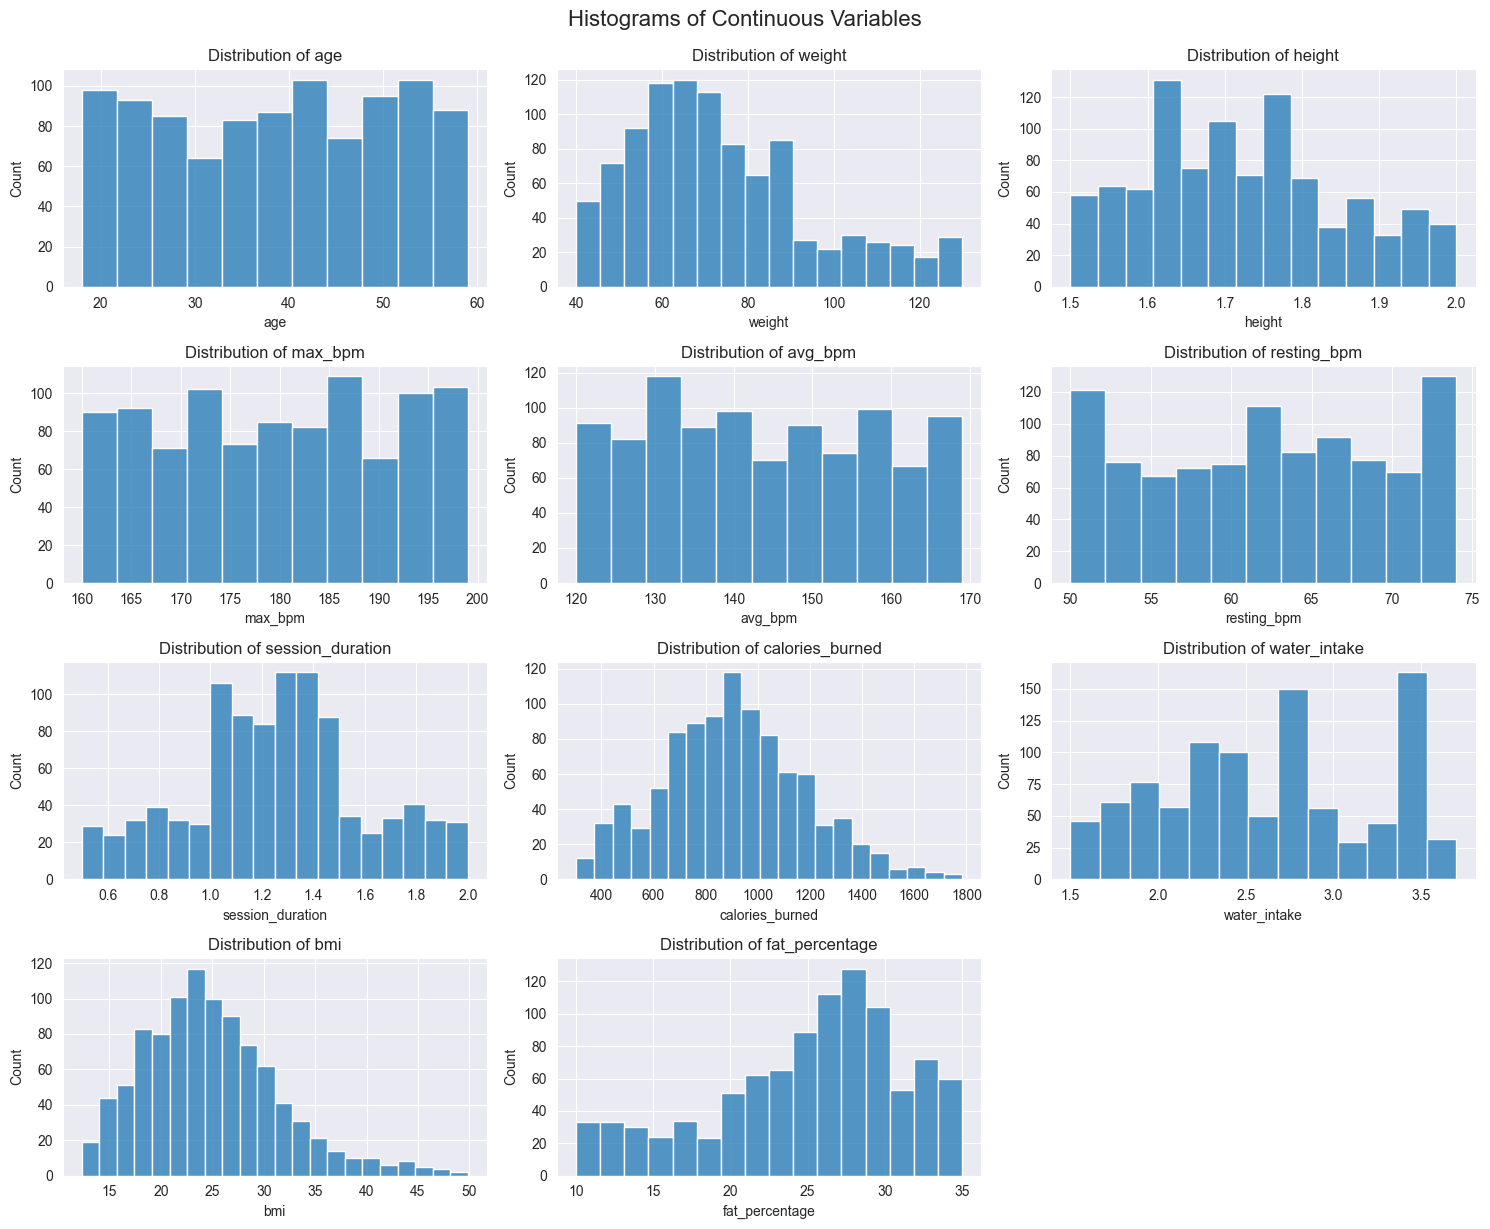

In [8]:
continuous_vars = ['age', 'weight', 'height', 'max_bpm',
                   'avg_bpm', 'resting_bpm', 'session_duration', 'calories_burned',
                   'water_intake', 'bmi', 'fat_percentage']

plt.figure(figsize=(15, 12))

for i, var in enumerate(continuous_vars, 1):
    plt.subplot(4, 3, i)
    sns.histplot(df[var])
    plt.title(f'Distribution of {var}')
    plt.tight_layout()
plt.suptitle('Histograms of Continuous Variables', y=1.02, fontsize=16)
plt.show()

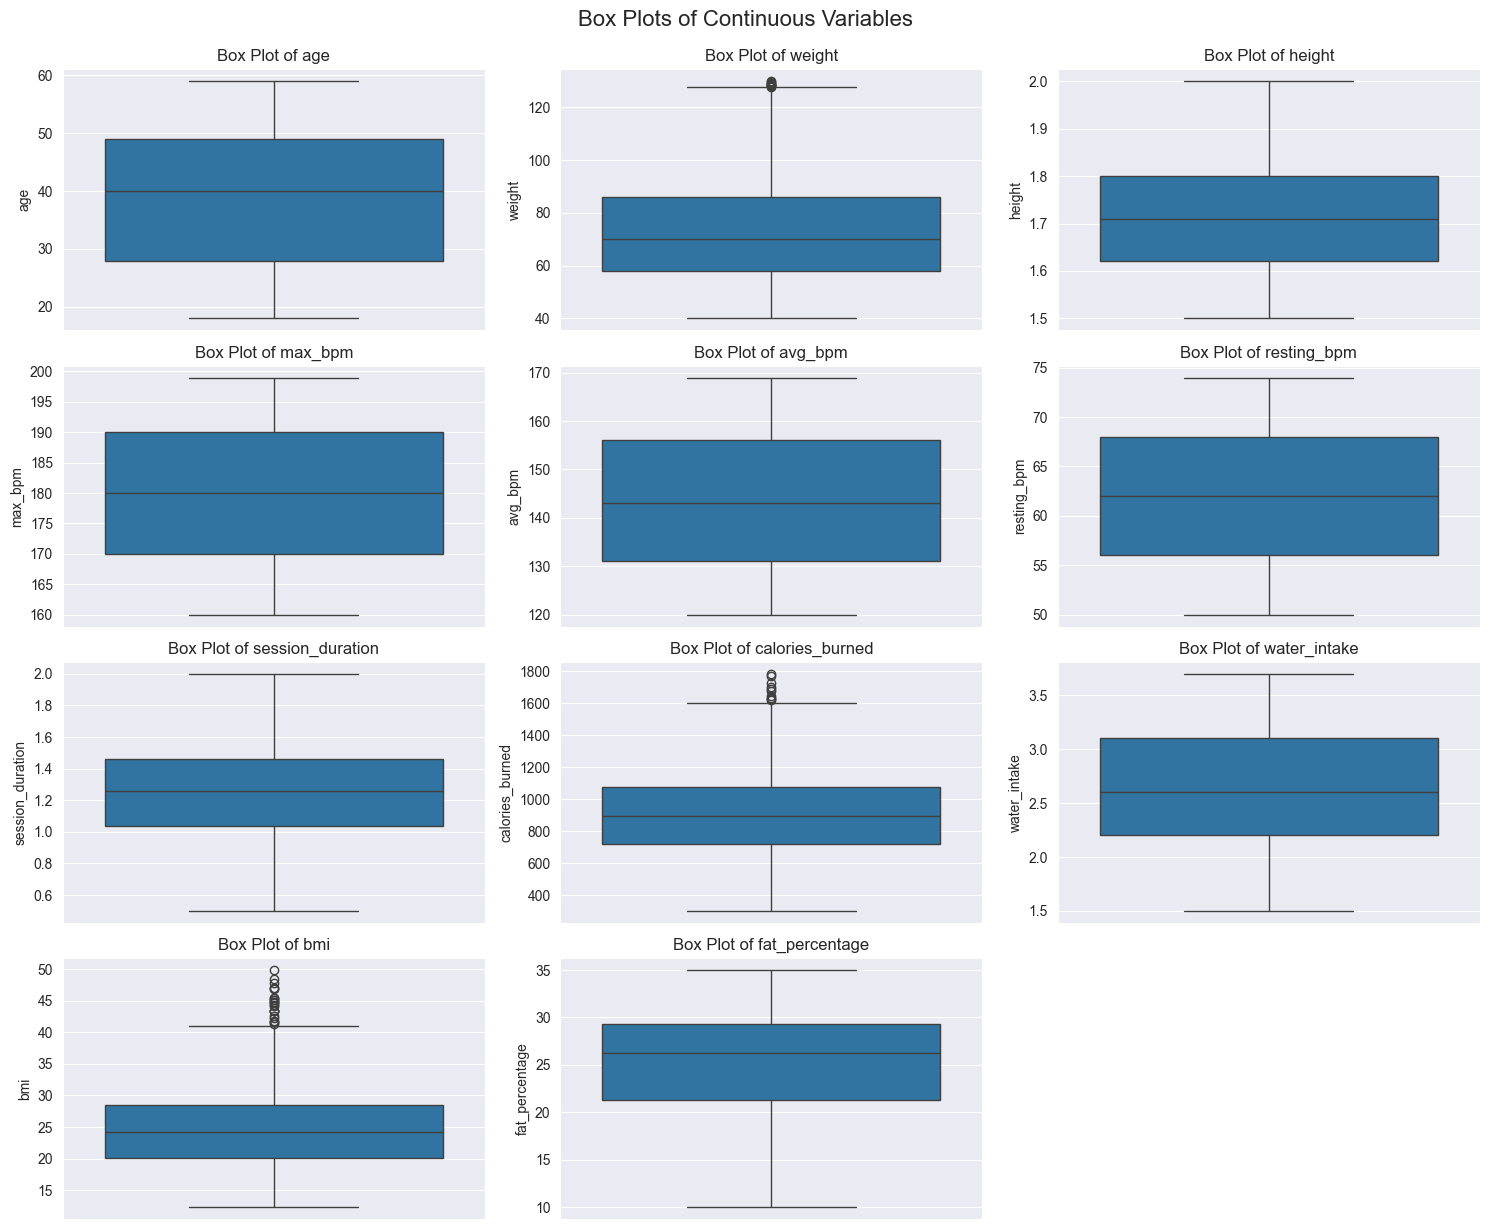

In [9]:
plt.figure(figsize=(15, 12))
for i, var in enumerate(continuous_vars, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(y=df[var])
    plt.title(f'Box Plot of {var}')
    plt.tight_layout()
plt.suptitle('Box Plots of Continuous Variables', y=1.02, fontsize=16)
plt.show()

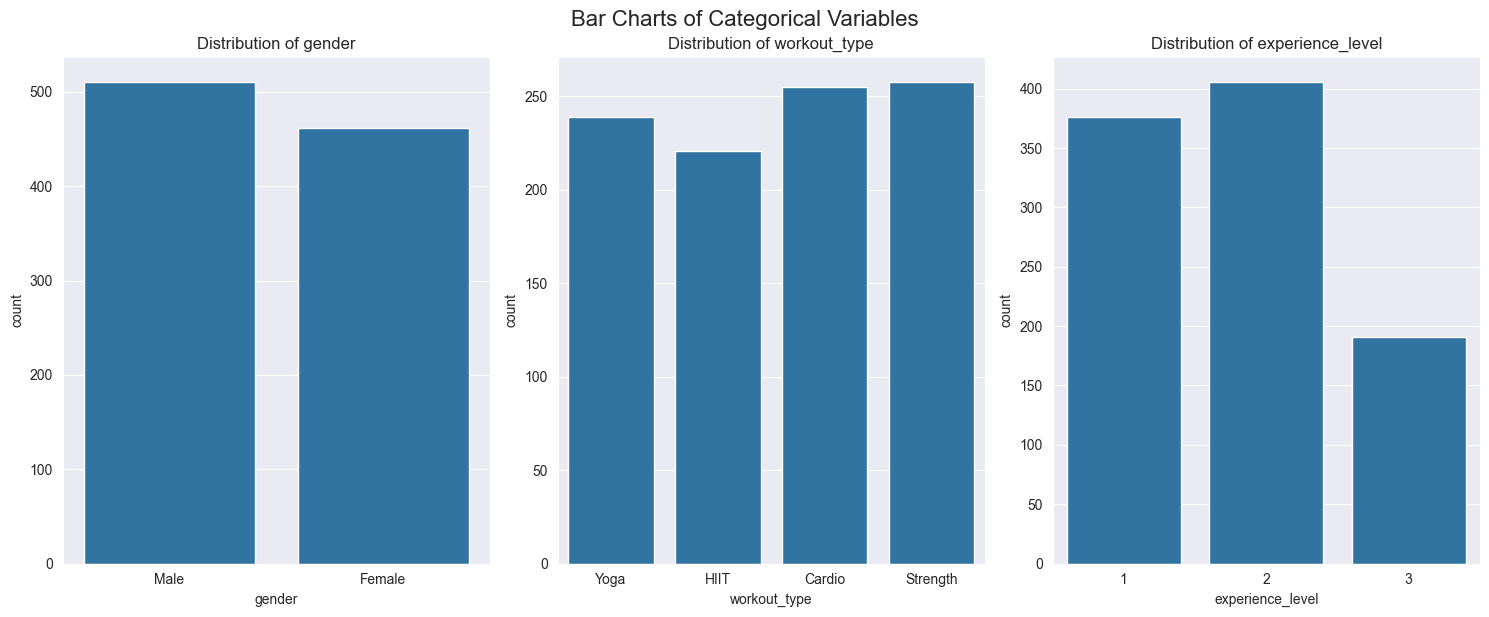

In [10]:
categorical_vars = ['gender', 'workout_type', 'experience_level']

plt.figure(figsize=(15, 6))

for i, var in enumerate(categorical_vars, 1):
    plt.subplot(1, 3, i)
    sns.countplot(x=df[var])
    plt.title(f'Distribution of {var}')
    plt.tight_layout()
plt.suptitle('Bar Charts of Categorical Variables', y=1.02, fontsize=16)
plt.show()

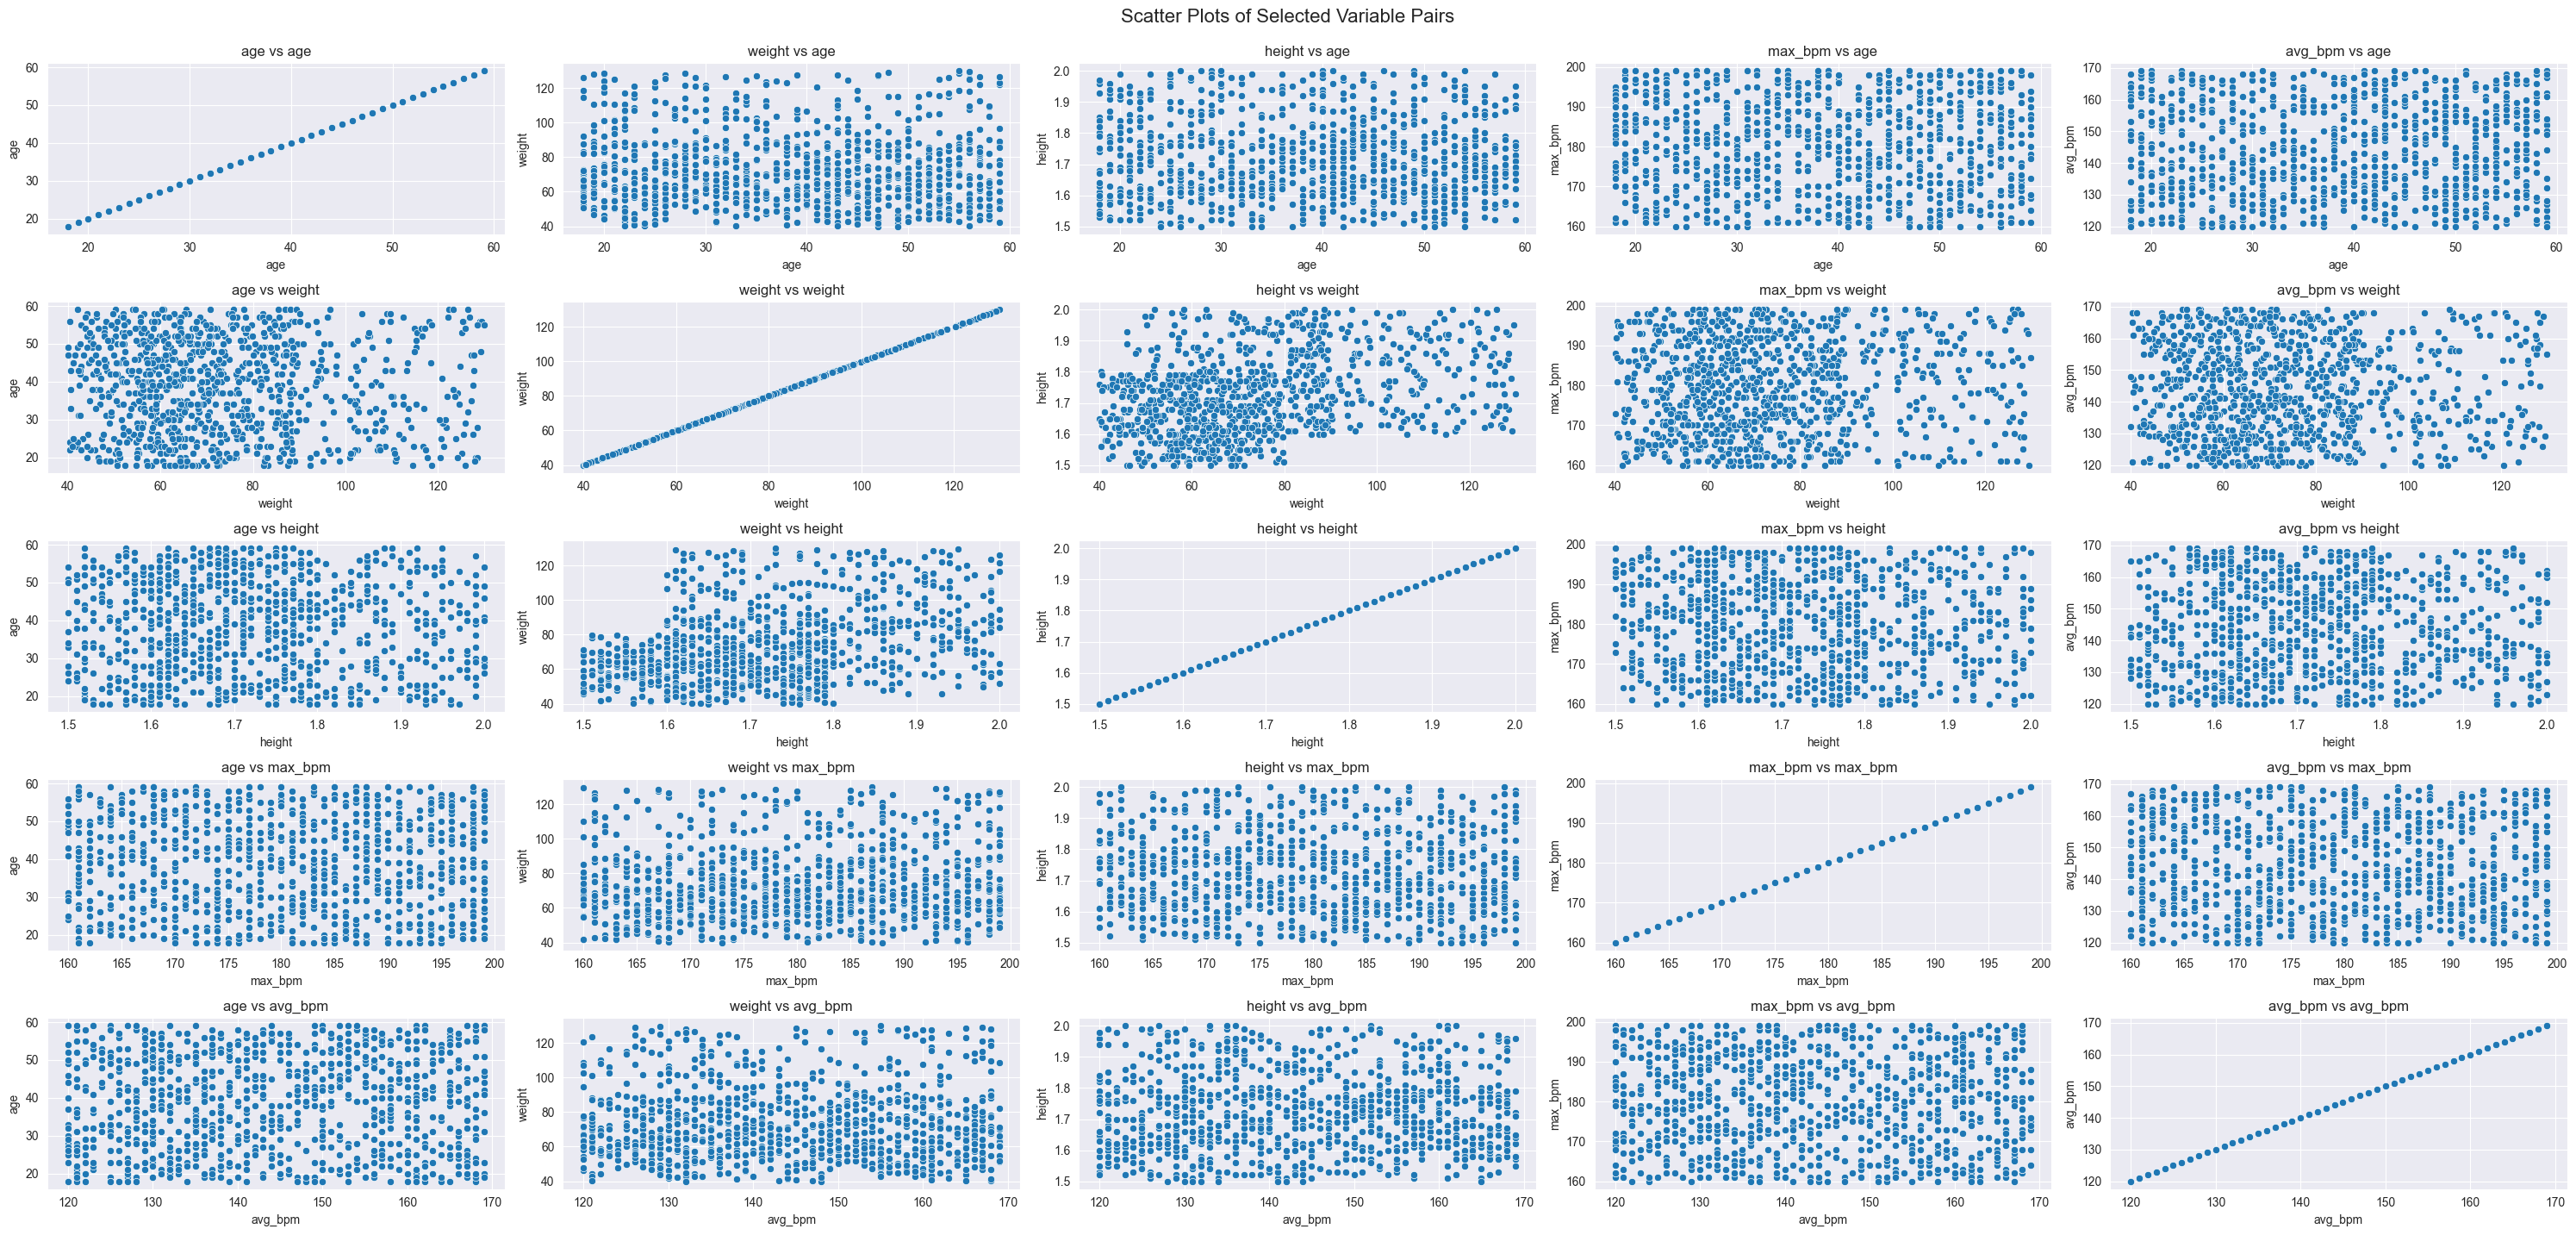

In [11]:
import itertools

features = continuous_vars[:-6]

plt.figure(figsize=(30, 14))

for i, (x, y) in enumerate(itertools.product(features, features), 1):
    plt.subplot(len(features), len(features), i)
    sns.scatterplot(x=df[x], y=df[y])
    plt.title(f'{y} vs {x}')
    plt.xlabel(x)
    plt.ylabel(y)
    plt.tight_layout()
plt.suptitle('Scatter Plots of Selected Variable Pairs', y=1.02, fontsize=16)
plt.show()

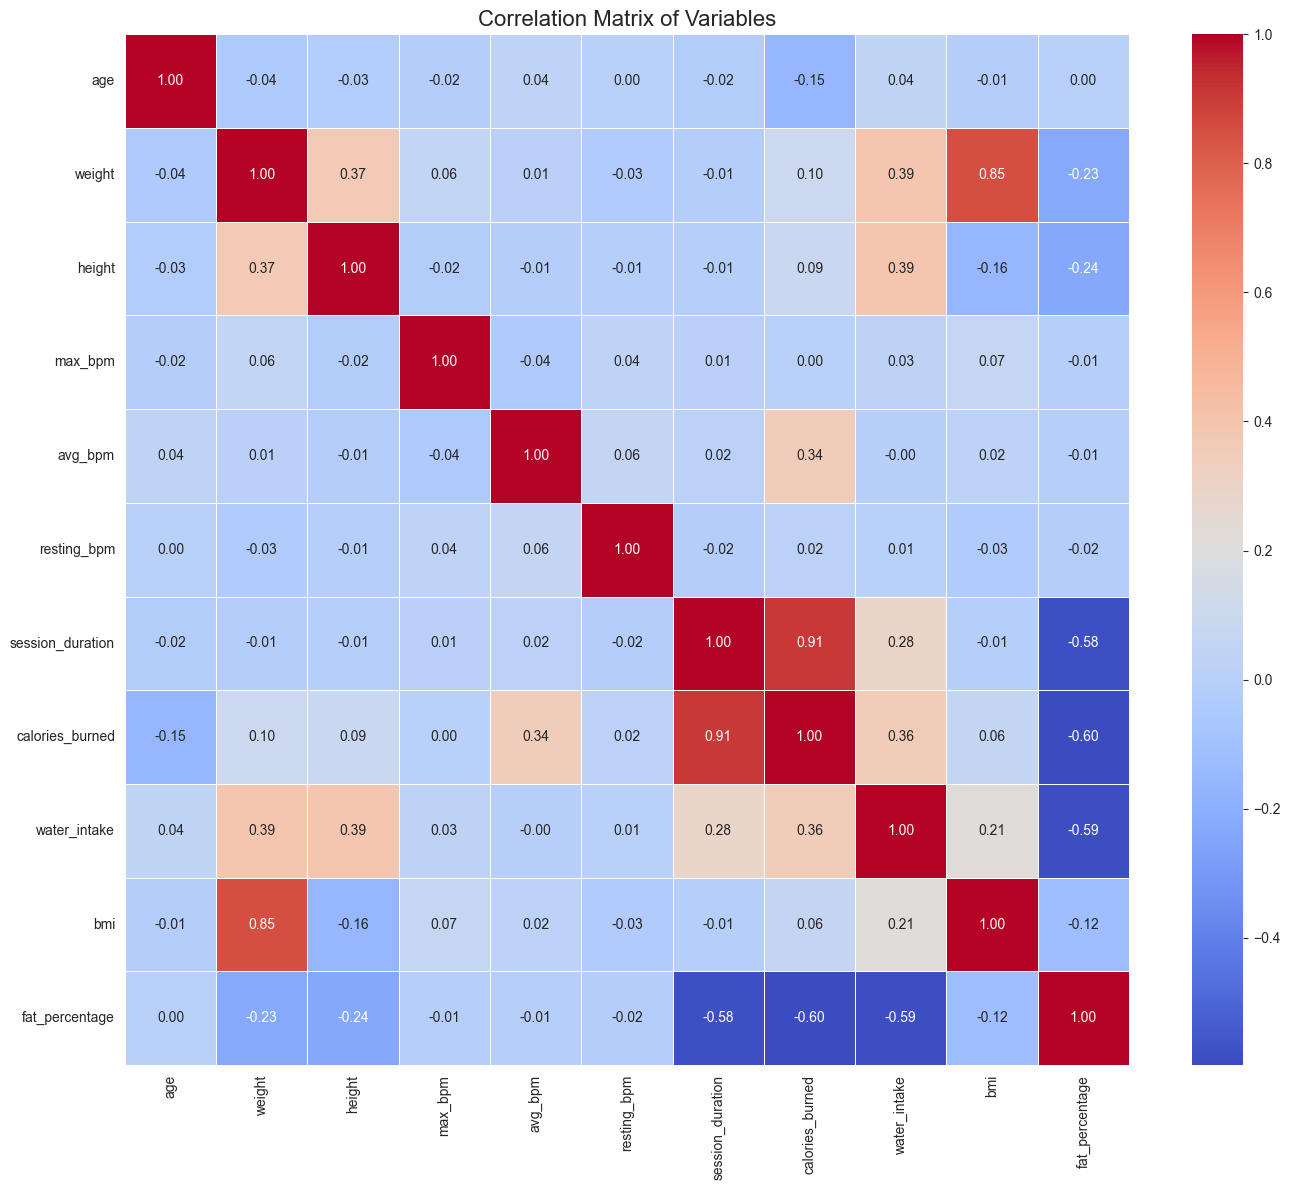

In [12]:
corr_matrix = df[continuous_vars].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Variables', fontsize=16)
plt.tight_layout()
plt.show()

### Task 2

In [13]:
df.isnull().sum()

age                  0
gender               0
weight               0
height               0
max_bpm              0
avg_bpm              0
resting_bpm          0
session_duration     0
calories_burned      0
workout_type         0
fat_percentage       0
water_intake         0
workout_frequency    0
experience_level     0
bmi                  0
dtype: int64

In [14]:
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)][column]
    return outliers, lower_bound, upper_bound



Outliers in age:
Count: 0 (0.00%)
Lower bound: -3.5, Upper bound: 80.5


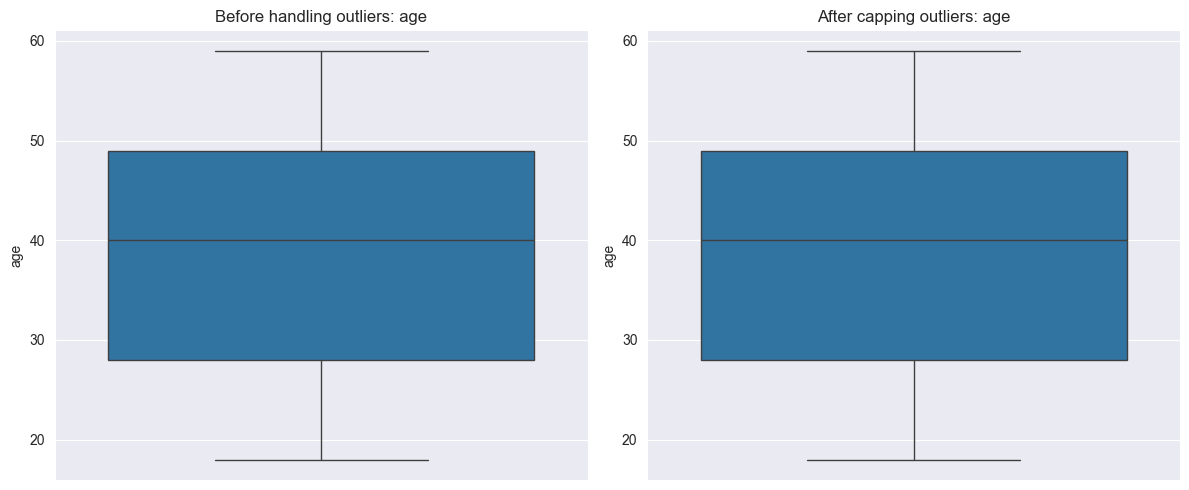


Outliers in weight:
Count: 9 (0.92%)
Lower bound: 16.250000000000007, Upper bound: 127.85


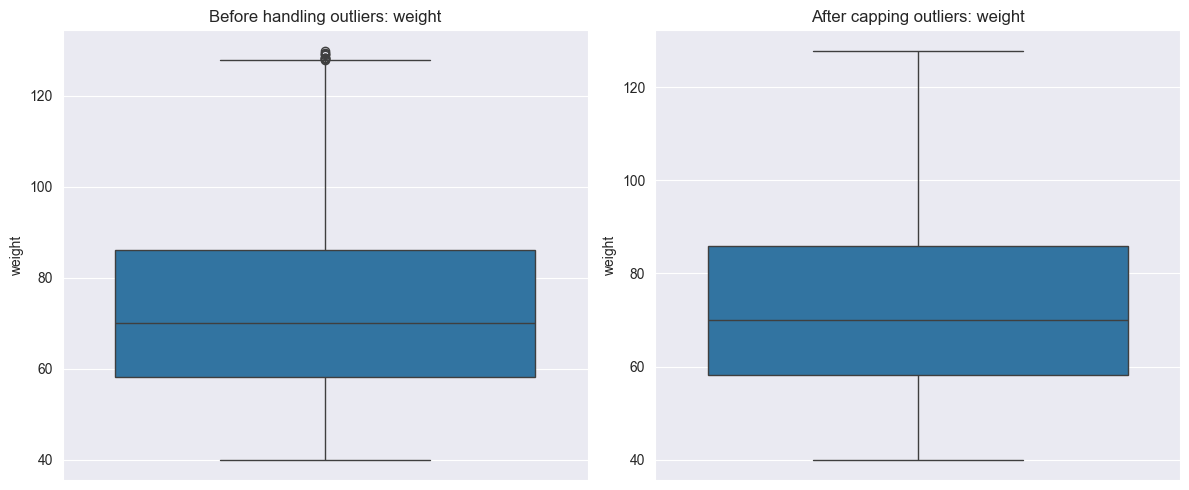


Outliers in height:
Count: 0 (0.00%)
Lower bound: 1.35, Upper bound: 2.07


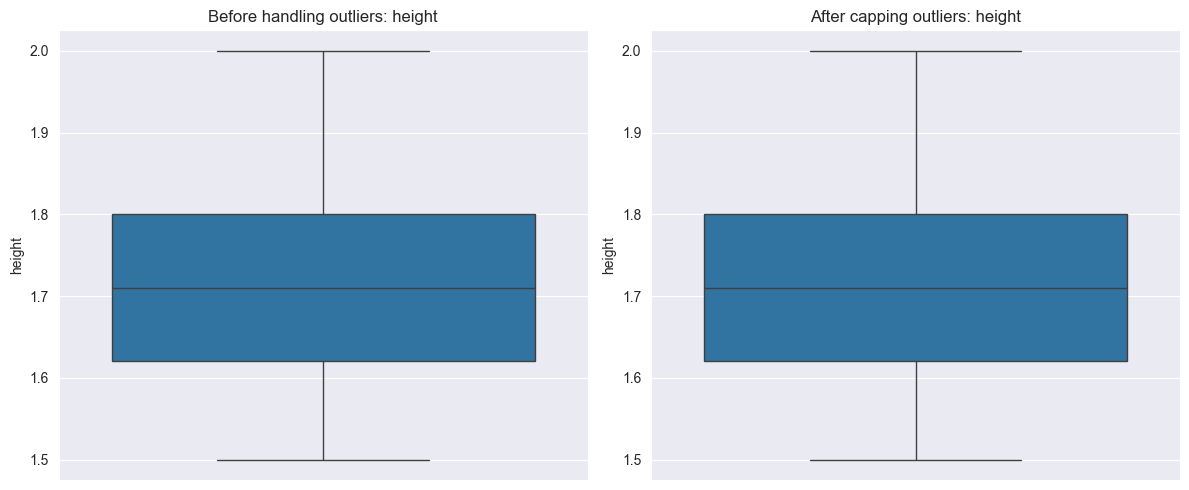


Outliers in max_bpm:
Count: 0 (0.00%)
Lower bound: 140.0, Upper bound: 220.0


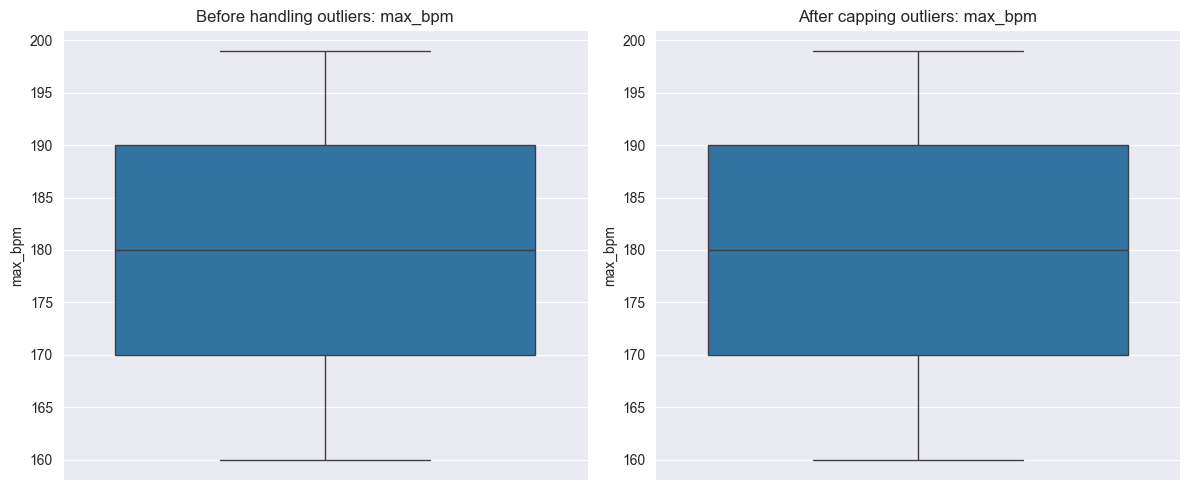


Outliers in avg_bpm:
Count: 0 (0.00%)
Lower bound: 93.5, Upper bound: 193.5


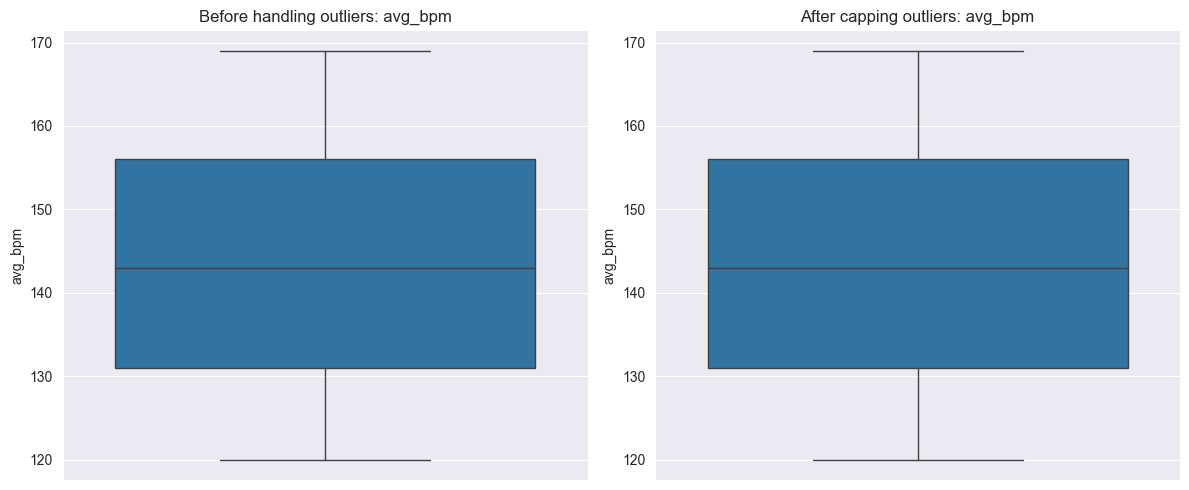


Outliers in resting_bpm:
Count: 0 (0.00%)
Lower bound: 38.0, Upper bound: 86.0


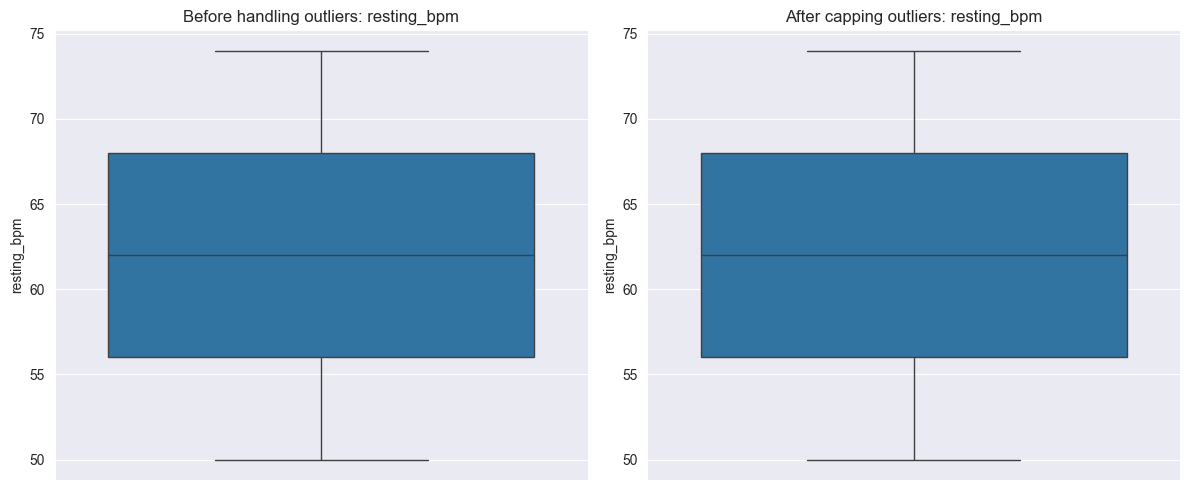


Outliers in session_duration:
Count: 0 (0.00%)
Lower bound: 0.41000000000000014, Upper bound: 2.09


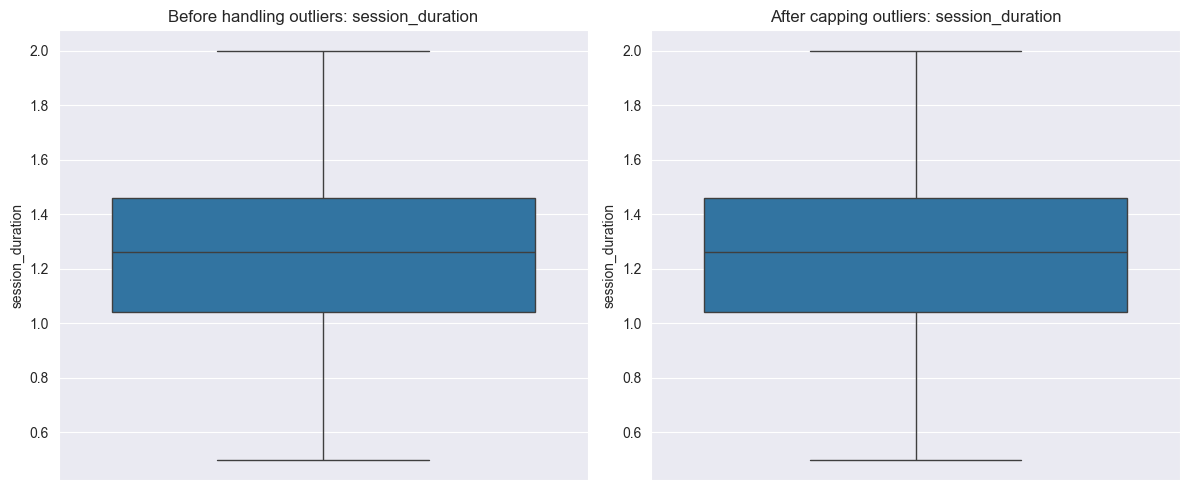


Outliers in calories_burned:
Count: 10 (1.03%)
Lower bound: 186.0, Upper bound: 1610.0


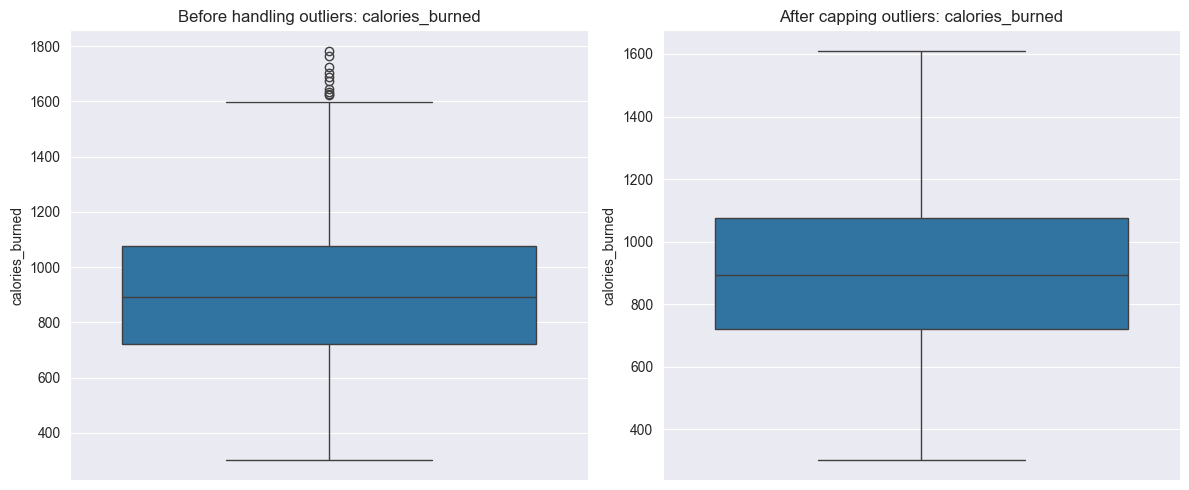


Outliers in water_intake:
Count: 0 (0.00%)
Lower bound: 0.8500000000000003, Upper bound: 4.45


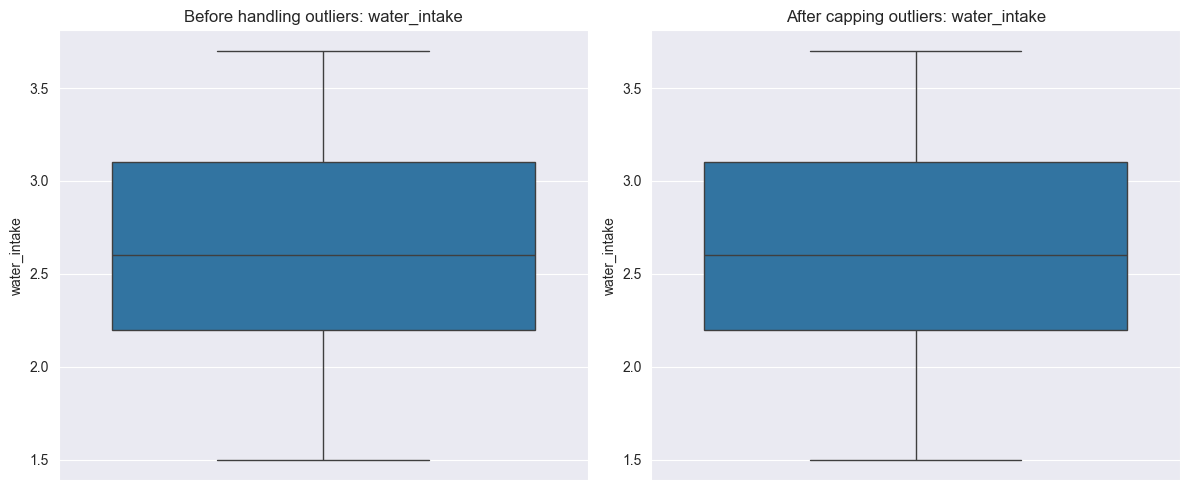


Outliers in bmi:
Count: 25 (2.57%)
Lower bound: 7.4350000000000005, Upper bound: 41.235


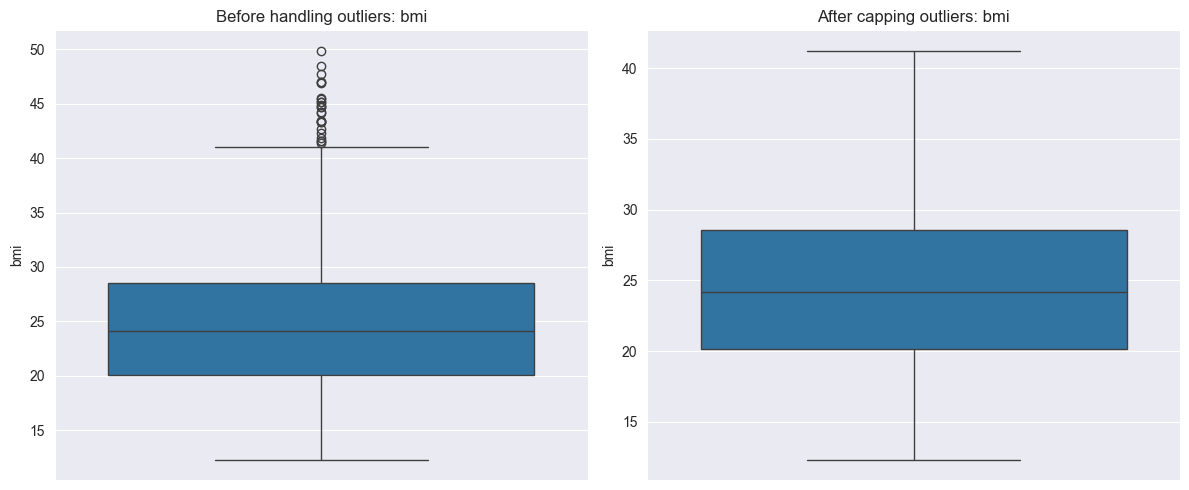


Outliers in fat_percentage:
Count: 0 (0.00%)
Lower bound: 9.3, Upper bound: 41.3


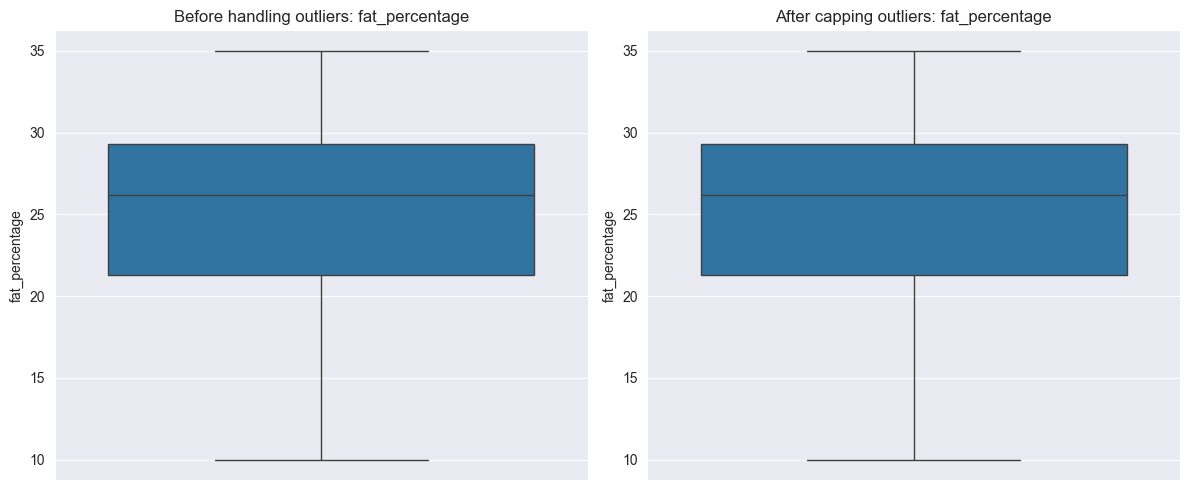

In [15]:
df_no_outliers = df.copy()

for var in continuous_vars:
    outliers, lower_bound, upper_bound = detect_outliers(df_no_outliers, var)
    outlier_count = len(outliers)
    outlier_percent = (outlier_count / len(df_no_outliers)) * 100

    print(f"\nOutliers in {var}:")
    print(f"Count: {outlier_count} ({outlier_percent:.2f}%)")
    print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")

    # Visualize before capping
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.boxplot(y=df_no_outliers[var])
    plt.title(f'Before handling outliers: {var}')

    # Cap outliers instead of removing them
    df_no_outliers[var] = df_no_outliers[var].clip(lower=lower_bound, upper=upper_bound)

    # Visualize after capping
    plt.subplot(1, 2, 2)
    sns.boxplot(y=df_no_outliers[var])
    plt.title(f'After capping outliers: {var}')

    plt.tight_layout()
    plt.show()

In [16]:
from sklearn.preprocessing import LabelEncoder

df_transformed = df_no_outliers.copy()

to_encode = ['gender', 'workout_type']

le = LabelEncoder()

for var in to_encode:
    df_transformed[var] = le.fit_transform(df_transformed[var])

In [17]:
df_transformed.head()

,age,gender,weight,height,max_bpm,avg_bpm,resting_bpm,session_duration,calories_burned,workout_type,fat_percentage,water_intake,workout_frequency,experience_level,bmi
0,56,1,88.3,1.71,180,157,60,1.69,1313.0,3,12.6,3.5,4,3,30.20
1,46,0,74.9,1.53,179,151,66,1.30,883.0,1,33.9,2.1,4,2,32.00
2,32,0,68.1,1.66,167,122,54,1.11,677.0,0,33.4,2.3,4,2,24.71
3,25,1,53.2,1.70,190,164,56,0.59,532.0,2,28.8,2.1,3,1,18.41
4,38,1,46.1,1.79,188,158,68,0.64,556.0,2,29.2,2.8,3,1,14.39


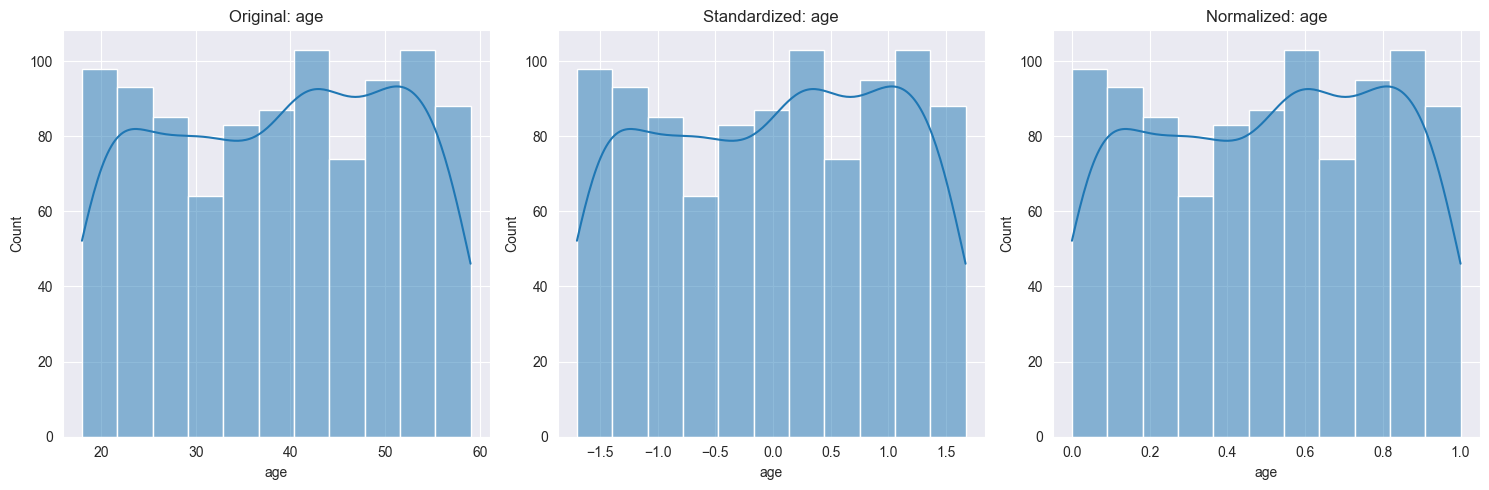

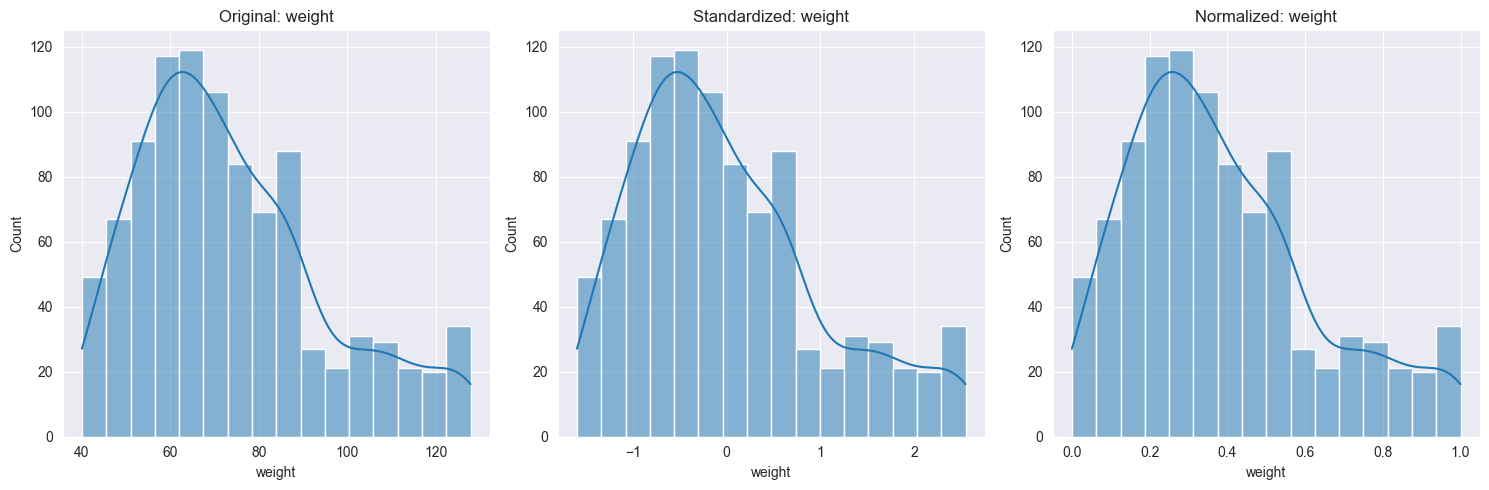

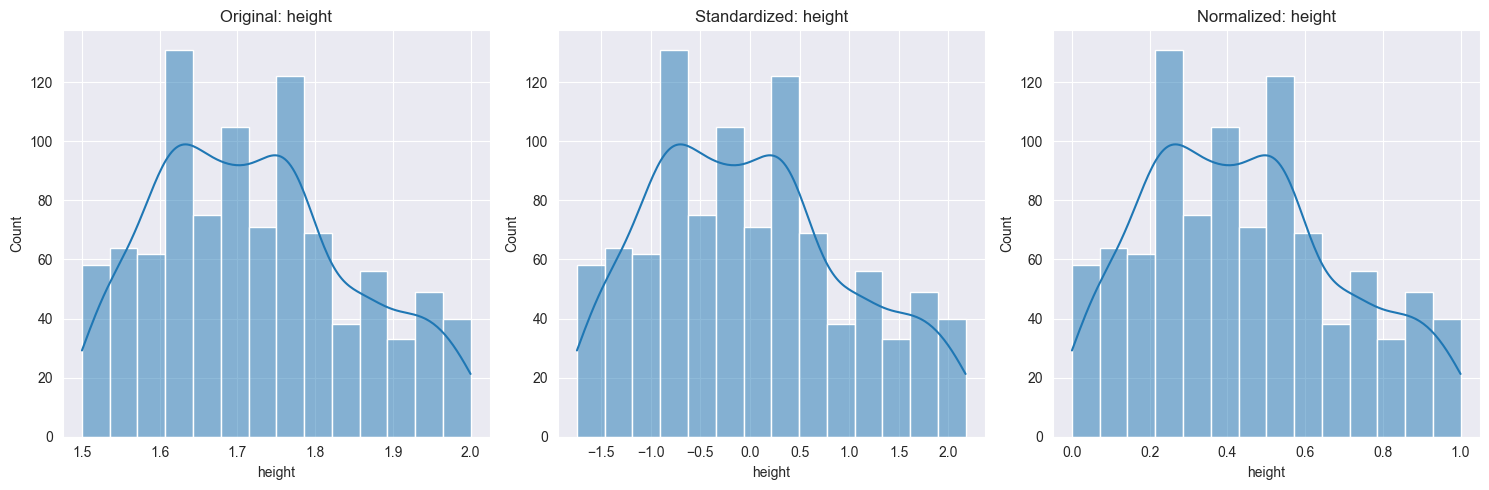

In [18]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Standardize (z-score) continuous variables
scaler = StandardScaler()
df_standardized = df_transformed.copy()
df_standardized[continuous_vars] = scaler.fit_transform(df_transformed[continuous_vars])

# Min-Max scaling (normalize to 0-1 range)
normalizer = MinMaxScaler()
df_normalized = df_transformed.copy()
df_normalized[continuous_vars] = normalizer.fit_transform(df_transformed[continuous_vars])

# Compare distributions before and after standardization for a few key variables
for var in continuous_vars[:3]:
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    sns.histplot(df_transformed[var], kde=True)
    plt.title(f'Original: {var}')

    plt.subplot(1, 3, 2)
    sns.histplot(df_standardized[var], kde=True)
    plt.title(f'Standardized: {var}')

    plt.subplot(1, 3, 3)
    sns.histplot(df_normalized[var], kde=True)
    plt.title(f'Normalized: {var}')

    plt.tight_layout()
    plt.show()

### Task 3

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

#### Hypothesis 1: There is a significant difference in calories burned between different workout types
Null Hypothesis (H0): Mean calories burned are equal across all workout types

Alternative Hypothesis (H1): Mean calories burned differ for at least one workout type

In [29]:
model = ols('calories_burned ~ C(workout_type)', data=df_transformed).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print("\nANOVA Results:")
display(anova_table)

alpha = 0.05
p_value = anova_table.iloc[0]['PR(>F)']
if p_value < alpha:
    print(f"Since p-value ({p_value:.4f}) < alpha ({alpha}), we reject the null hypothesis.")
    print("There is a significant difference in calories burned between at least two workout types.")
else:
    print(f"Since p-value ({p_value:.4f}) > alpha ({alpha}), we fail to reject the null hypothesis.")
    print("There is no significant difference in calories burned between workout types.")


ANOVA Results:


,sum_sq,df,F,PR(>F)
C(workout_type),1.964719e+05,3.0,0.895212,0.443072
Residual,7.088866e+07,969.0,NaN,NaN


Since p-value (0.4431) > alpha (0.05), we fail to reject the null hypothesis.
There is no significant difference in calories burned between workout types.


#### Hypothesis 2: There is a correlation between Body Fat percentage and Calories burned
Null Hypothesis (H0): There is no correlation between Body Fat percentage and Calories burned (r = 0)

Alternative Hypothesis (H1): There is a correlation between Body Fat percentage and Calories burned (r ≠ 0)


Pearson correlation coefficient (r): -0.5961
P-value: 1.1980704551634249e-94
Since p-value (0.0000) < alpha (0.05), we reject the null hypothesis.
There is a significant negative correlation (r = -0.5961) between Body Fat percentage and Calories burned.


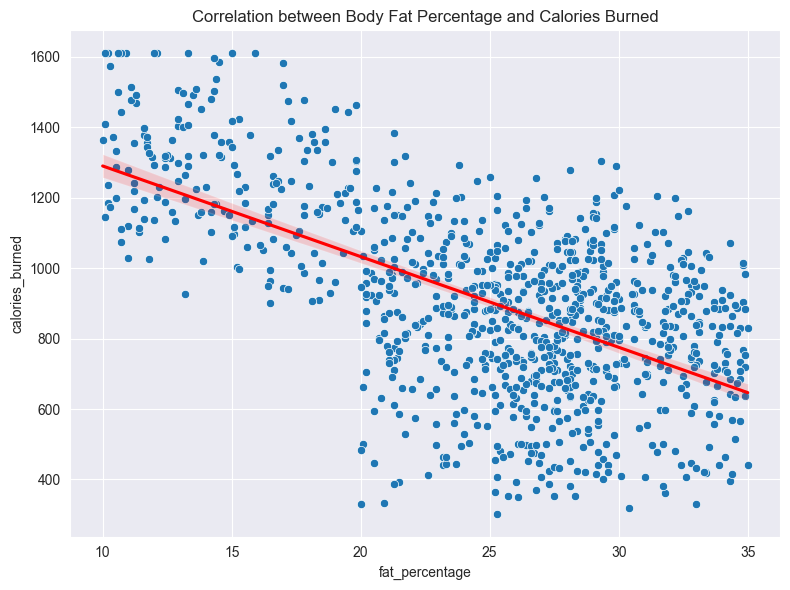

In [34]:
correlation, p_value = stats.pearsonr(df_transformed['fat_percentage'], df_transformed['calories_burned'])
print(f"\nPearson correlation coefficient (r): {correlation:.4f}")
print(f"P-value: {p_value}")

alpha = 0.05
if p_value < alpha:
    print(f"Since p-value ({p_value:.4f}) < alpha ({alpha}), we reject the null hypothesis.")

    print(
        f"There is a significant {'positive' if correlation > 0 else 'negative'} correlation (r = {correlation:.4f}) between Body Fat percentage and Calories burned.")

    plt.figure(figsize=(8, 6))
    sns.scatterplot(x='fat_percentage', y='calories_burned', data=df_transformed)
    plt.title('Correlation between Body Fat Percentage and Calories Burned')
    plt.xlabel('Body Fat Percentage (%)')
    plt.ylabel('Calories Burned')

    sns.regplot(x='fat_percentage', y='calories_burned', data=df_transformed, scatter=False, color='red')
    plt.tight_layout()
    plt.show()
else:
    print(f"Since p-value ({p_value:.4f}) > alpha ({alpha}), we fail to reject the null hypothesis.")
    print("There is no significant correlation between Body Fat percentage and Calories burned.")

#### Hypothesis 3: Males and Females have different average BMI values
Null Hypothesis (H0): Mean BMI is equal for males and females

Alternative Hypothesis (H1): Mean BMI differs between males and females


Checking normality assumption for t-test:

Shapiro-Wilk Test for Male BMI:
W-statistic: 0.9768, p-value: 0.0000

Shapiro-Wilk Test for Female BMI:
W-statistic: 0.9928, p-value: 0.0253

Levene's Test for Equality of Variances:
W-statistic: 107.3585, p-value: 0.0000

Independent t-test results (equal_var=False):
t-statistic: 10.4390, p-value: 0.0000

Mean BMI for Males: 26.72
Mean BMI for Females: 22.73
Difference in means: 3.99

Since p-value (0.0000) < alpha (0.05), we reject the null hypothesis.
There is a significant difference in mean BMI between males and females.


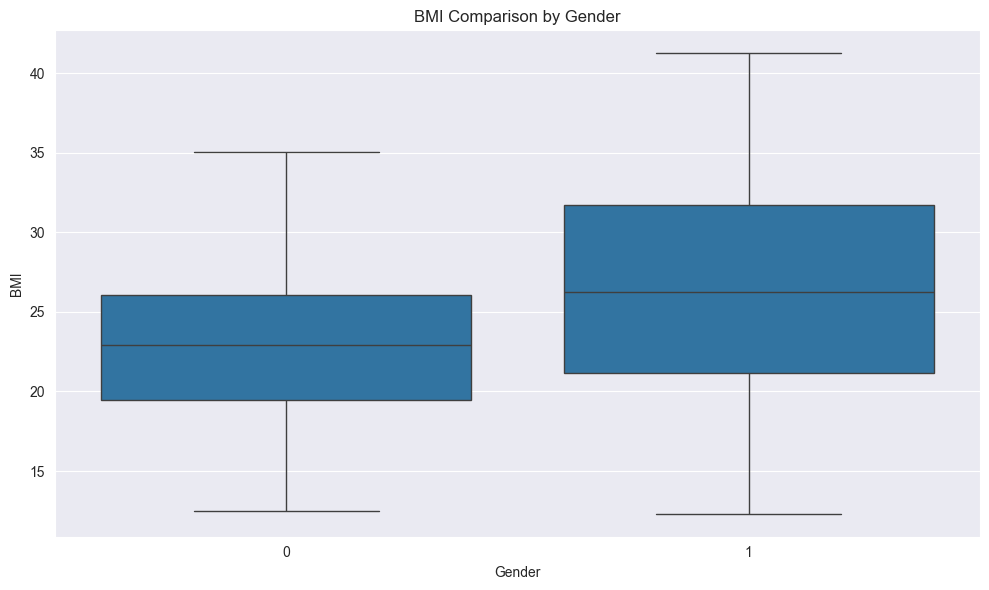

In [39]:
male_bmi = df_transformed[df_transformed['gender'] == 1]['bmi']
female_bmi = df_transformed[df_transformed['gender'] == 0]['bmi']

print("\nChecking normality assumption for t-test:")
print("\nShapiro-Wilk Test for Male BMI:")
shapiro_male = stats.shapiro(male_bmi)
print(f"W-statistic: {shapiro_male[0]:.4f}, p-value: {shapiro_male[1]:.4f}")

print("\nShapiro-Wilk Test for Female BMI:")
shapiro_female = stats.shapiro(female_bmi)
print(f"W-statistic: {shapiro_female[0]:.4f}, p-value: {shapiro_female[1]:.4f}")

print("\nLevene's Test for Equality of Variances:")
levene = stats.levene(male_bmi, female_bmi)
print(f"W-statistic: {levene[0]:.4f}, p-value: {levene[1]:.4f}")

equal_var = levene[1] >= 0.05

t_stat, p_value = stats.ttest_ind(male_bmi, female_bmi, equal_var=equal_var)
print(f"\nIndependent t-test results (equal_var={equal_var}):")
print(f"t-statistic: {t_stat:.4f}, p-value: {p_value:.4f}")

male_mean = male_bmi.mean()
female_mean = female_bmi.mean()
print(f"\nMean BMI for Males: {male_mean:.2f}")
print(f"Mean BMI for Females: {female_mean:.2f}")
print(f"Difference in means: {abs(male_mean - female_mean):.2f}")

alpha = 0.05
if p_value < alpha:
    print(f"\nSince p-value ({p_value:.4f}) < alpha ({alpha}), we reject the null hypothesis.")
    print("There is a significant difference in mean BMI between males and females.")
else:
    print(f"\nSince p-value ({p_value:.4f}) > alpha ({alpha}), we fail to reject the null hypothesis.")
    print("There is no significant difference in mean BMI between males and females.")

plt.figure(figsize=(10, 6))
sns.boxplot(x='gender', y='bmi', data=df_transformed)
plt.title('BMI Comparison by Gender')
plt.xlabel('Gender')
plt.ylabel('BMI')
plt.tight_layout()
plt.show()

### Task 4

### Task 5

### Task 6